<a href="https://colab.research.google.com/github/seifnasser879/Driver-Drowsiness/blob/main/notebooks/yolov11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 7.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="xxxx")
project = rf.workspace("fyp-vzed3").project("drivers-drowsiness-detection")
version = project.version(1)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drivers-Drowsiness-Detection-1 in yolov11:: 100%|██████████| 18946/18946 [00:02<00:00, 7823.68it/s]


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10)

print("Training Finished")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Drivers-Drowsiness-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1137.0±438.2 MB/s, size: 22.1 KB)
val: Scanning /content/Drivers-Drowsiness-Detection-1/test/labels.cache... 948 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 948/948 248.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 5.5it/s 10.9s
                   all        948        948      0.983      0.986      0.991      0.892
                 awake        391        391      0.977      0.988      0.988      0.897
                drowsy        557        557      0.989      0.984      0.993      0.888
Speed: 1.5ms preprocess, 3.9ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val-2
Precision: 0.9829445966725521
Recall: 0.9858788860351664
mAP50: 0.9905683

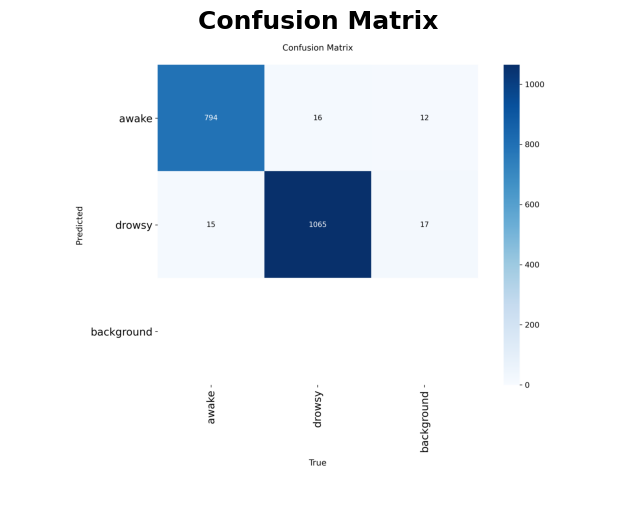

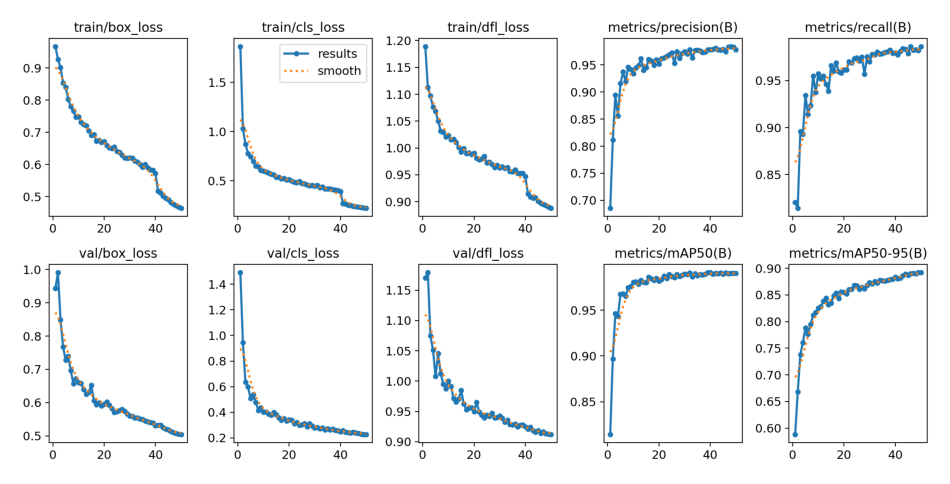

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    split="test"
)

print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

img = Image.open(
    "/content/runs/detect/train/confusion_matrix.png"
)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix",fontsize=18,fontweight="bold")
plt.show()



img = Image.open(
    "/content/runs/detect/train/results.png"
)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

results = model.predict(
    source="Drivers-Drowsiness-Detection-1/test/images",
    conf=0.5,
    save=True
)

print("Prediction complete!")


image 1/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091302_jpg.rf.17ebfd180b322cd4cc0bb71466308510.jpg: 640x640 1 drowsy, 9.1ms
image 2/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091305_jpg.rf.35352957b3ddaef8fa3da318ad2b2c29.jpg: 640x640 1 drowsy, 8.4ms
image 3/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091311_jpg.rf.eca4a5d3f8b985d28ee89d0fb121aca0.jpg: 640x640 1 awake, 8.1ms
image 4/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091337_jpg.rf.25c1843b59f912d57205e785e492b345.jpg: 640x640 1 drowsy, 8.8ms
image 5/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091338_jpg.rf.e5f55350045ddc858d6e493f7e7f4d73.jpg: 640x640 1 drowsy, 8.5ms
image 6/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091400_jpg.rf.4bf602fdeaf3b4860c47df203d7761d3.jpg: 640x640 1 drowsy, 12.7ms
image 7/948 /content/Drivers-Drowsiness-Detection-1/test/images/221023-091401_jpg.rf.5190051f44ef3a59fb1d69fe51f20a4d


0: 640x640 1 awake, 5.4ms
1: 640x640 1 drowsy, 5.4ms
2: 640x640 1 awake, 5.4ms
3: 640x640 1 awake, 5.4ms
4: 640x640 1 awake, 5.4ms
Speed: 2.4ms preprocess, 5.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


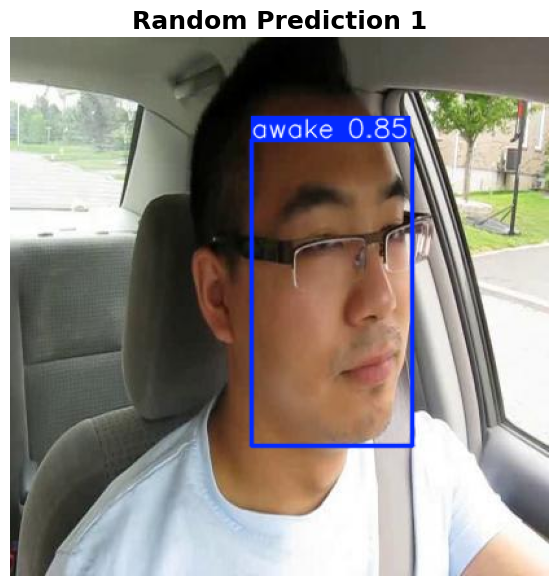

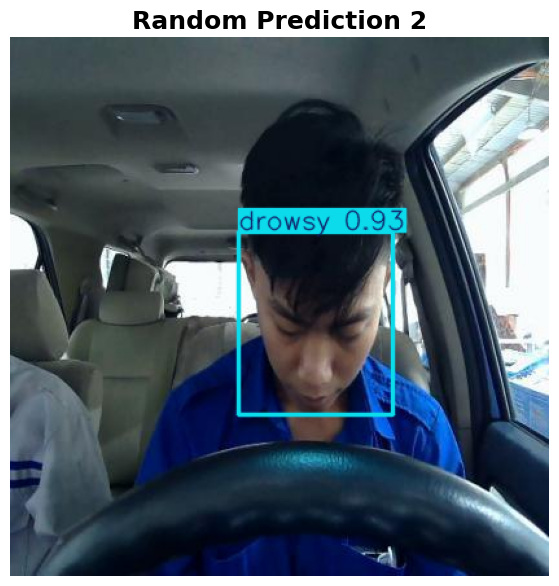

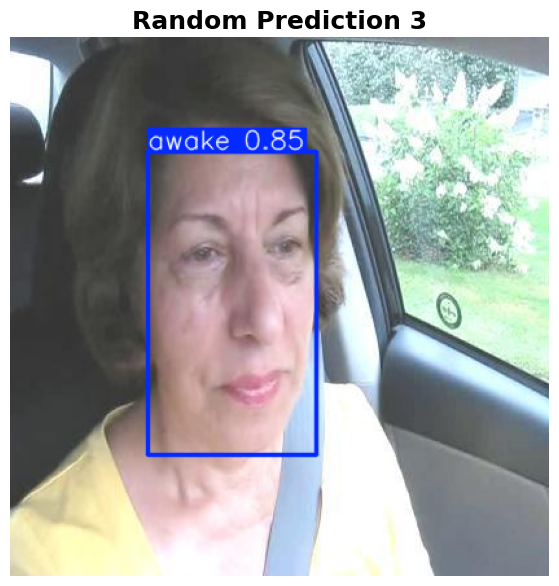

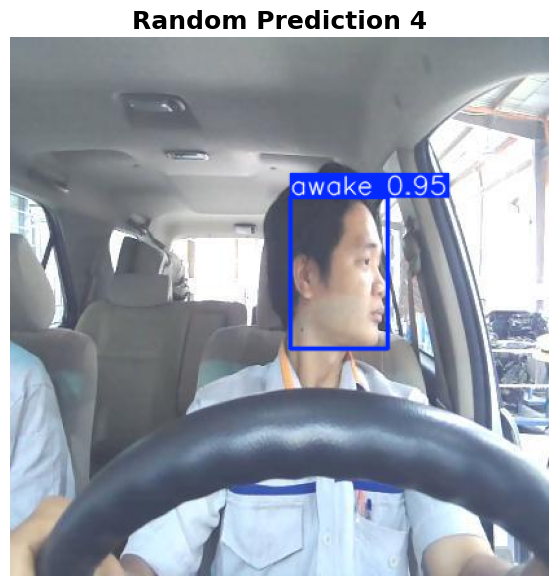

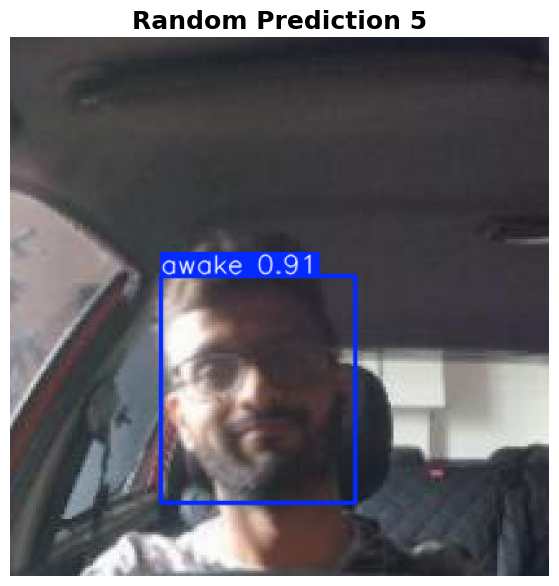

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os


image_paths = "Drivers-Drowsiness-Detection-1/test/images"


image_files = [
    os.path.join(image_paths, file)
    for file in os.listdir(image_paths)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))]


random_images = random.sample(
    image_files,
    min(5, len(image_files)))


results = model.predict(
    source=random_images,
    conf=0.5)


for i, result in enumerate(results):

    annotated_image = result.plot()

    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 7))
    plt.imshow(annotated_image)
    plt.axis("off")
    plt.title(f"Random Prediction {i + 1}",fontsize=18,fontweight="bold")
    plt.show()


image 1/1 /content/happy-mature-man-driving-car.jpg: 448x640 1 awake, 59.8ms
Speed: 2.2ms preprocess, 59.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


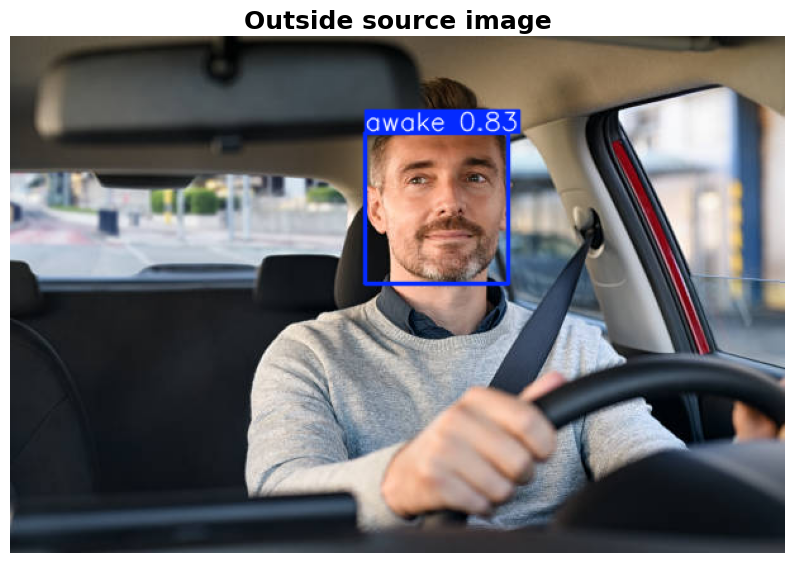

In [ ]:
results = model.predict(
    source="https://media.istockphoto.com/id/1413761196/photo/happy-mature-man-driving-car.jpg?s=612x612&w=0&k=20&c=cHortB6t2CuIicx-UzOiq2jyfXufja9vETTN9dmThG4=",
    conf=0.5
)
result=results[0]

annotated_image = result.plot()

annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(annotated_image)
plt.axis("off")
plt.title(f"Outside source image",fontsize=18,fontweight="bold")
plt.show()

